# Analyze sea-level predictions for Greenland and Antarctica by ISMIP6 / IPCC AR6

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

/var/folders/36/wz86phpn6ql32ksy750rmk1h0000gr/T/ipykernel_23148/1226147920.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [2]:
import numpy as np
import os
import pylab as plt
import pandas as pd
import seaborn as sns
import scipy

import matplotlib.lines as mlines
import matplotlib as mpl
import matplotlib.cm as cmx
import matplotlib.colors as colors

from utilities.data_loader import load_imbie_gis, load_ismip6_gis, load_imbie_ais, load_ismip6_ais
from utilities.helper import hist_start, hist_end, proj_start, proj_end, proj_time, secpera, ais_exp_dict

import warnings
warnings.filterwarnings('ignore')

## Plotting helpers

In [3]:
fontsize = 8
lw = 0.65
aspect_ratio = 0.35
markersize = 2

params = {
    "axes.linewidth": 0.25,
    "lines.linewidth": lw,
    "axes.labelsize": fontsize,
    "font.size": fontsize,
    "xtick.direction": "in",
    "xtick.labelsize": fontsize,
    "xtick.major.size": 2.5,
    "xtick.major.width": 0.25,
    "ytick.direction": "in",
    "ytick.labelsize": fontsize,
    "ytick.major.size": 2.5,
    "ytick.major.width": 0.25,
    "legend.fontsize": fontsize,
    "lines.markersize": markersize,
    "font.size": fontsize,
}

plt.rcParams.update(params)


grace_signal_lw = 0.75
mouginot_signal_lw = 0.75
imbie_signal_lw = 0.75
simulated_signal_lw = 0.15
imbie_signal_color = "#08519c"
imbie_sigma_color = "#6baed6"
imbie_sigma_colors = ["#6baed6", "#6baed6"]

simulated_signal_color = "0.7"

gt2cmSLE = 1.0 / 362.5 / 10.0

rcp_list = [26, 85]
rcp_dict = {26: "RCP 2.6", 45: "RCP 4.5", 85: "RCP 8.5"}
rcp_col_dict = {85: "#990002", 45: "#5492CD", 26: "#003466"}
rcp_shade_col_dict = {85: "#F4A582", 45: "#92C5DE", 26: "#4393C3"}
model_ls_dict = {"Model Uncertainty (ISMIP6)": "solid", "Parametric Uncertainty (AS19)": "dashed"}


def set_size(w, h, ax=None):
    """ w, h: width, height in inches """

    if not ax:
        ax = plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w) / (r - l)
    figh = float(h) / (t - b)
    ax.figure.set_size_inches(figw, figh)



## Load ISMIP6 projections

### AR6 Adjustments

**AR6** Table 9.2 and Figures 9.

For GIS and AIS, **AR6** adds the historical contribution of 0.19 mm/yr ([GIS](https://github.com/BrodiePearson/IPCC_AR6_Chapter9_Figures/blob/main/Plotting_code_and_data/Fig9_17_GIS_synth/Plot_Figure/Plot_Greenland_Timeseries.m))
and 0.33 mm/yr ([AIS](https://github.com/BrodiePearson/IPCC_AR6_Chapter9_Figures/blob/main/Plotting_code_and_data/Fig9_18_AIS_synth/Plot_Figure/Plot_Antarctic_Timeseries.m)) in 2100 relative to 2015

Note: 1cm SLE = 3625 Gt is used for conversion from cm SLE to Gt.


In [4]:
ismip6_ais = load_ismip6_ais(remove_ctrl=False)
ismip6_ais["Hist. Adj. Cumulative ice sheet mass change (Gt)"] = ismip6_ais["Cumulative ice sheet mass change (Gt)"] - (ismip6_ais["Year"] > proj_start) * (ismip6_ais["Year"] - proj_start) * 0.033 * 362.5 * 10
ismip6_ais["IS"] = "AIS"

ismip6_gis = load_ismip6_gis(remove_ctrl=False)
ismip6_gis["Hist. Adj. Cumulative ice sheet mass change (Gt)"] = ismip6_gis["Cumulative ice sheet mass change (Gt)"] - (ismip6_gis["Year"] > proj_start) * (ismip6_gis["Year"] - proj_start) * 0.019 * 362.5 * 10
ismip6_gis["IS"] = "GIS"

ismip6 = pd.concat([ismip6_ais, ismip6_gis])

ismip6_ais_ctrl_removed = load_ismip6_ais(remove_ctrl=True)
ismip6_ais_ctrl_removed["Hist. Adj. Cumulative ice sheet mass change (Gt)"] = ismip6_ais_ctrl_removed["Cumulative ice sheet mass change (Gt)"] - (ismip6_ais_ctrl_removed["Year"] > proj_start) * (ismip6_ais_ctrl_removed["Year"] - proj_start) * 0.033 * 362.5 * 10
ismip6_ais_ctrl_removed["IS"] = "AIS"

ismip6_gis_ctrl_removed = load_ismip6_gis(remove_ctrl=True)
ismip6_gis_ctrl_removed["Hist. Adj. Cumulative ice sheet mass change (Gt)"] = ismip6_gis_ctrl_removed["Cumulative ice sheet mass change (Gt)"] - (ismip6_gis_ctrl_removed["Year"] > proj_start) * (ismip6_gis_ctrl_removed["Year"] - proj_start) * 0.019 * 362.5 * 10
ismip6_gis_ctrl_removed["IS"] = "GIS"

ismip6_ctrl_removed = pd.concat([ismip6_ais_ctrl_removed, ismip6_gis_ctrl_removed])

## ISMIP6 in numbers

In [5]:
for ice_sheet in ["AIS", "GIS"]:

    df = ismip6[ismip6["IS"] == ice_sheet]
    ng = len(df["Group"].unique())
    nm = len(df["Model"].unique())
    ne = len(df["Exp"].unique())
    
    print(f"ISMIP6 {ice_sheet}:\n")
    print(f"Number of modeling groups participated: {ng}")
    print(f"Number of ice sheet model configurations used: {nm}")
    print(f"Number of experiments: {ne}\n")

ISMIP6 AIS:

Number of modeling groups participated: 13
Number of ice sheet model configurations used: 14
Number of experiments: 21

ISMIP6 GIS:

Number of modeling groups participated: 13
Number of ice sheet model configurations used: 18
Number of experiments: 9



In [25]:
ismip6

,Unnamed: 0,Year,Cumulative ice sheet mass change (Gt),Group,Model,Exp,RCP,Rate of surface mass balance anomaly (Gt/yr),Rate of ice sheet mass change (Gt/yr),Hist. Adj. Cumulative ice sheet mass change (Gt),IS,SLE (cm),Cumulative surface mass balance anomaly (Gt),Cumulative ice dynamics anomaly (Gt),Rate of ice dynamics anomaly (Gt/yr)
0,0,2005.0,-8235.500000,UCIJPL,ISSM,exp13,85,NaN,791.700000,-8235.500000,AIS,NaN,NaN,NaN,NaN
1,1,2006.0,-7443.800000,UCIJPL,ISSM,exp13,85,NaN,818.090000,-7443.800000,AIS,NaN,NaN,NaN,NaN
2,2,2007.0,-6599.320000,UCIJPL,ISSM,exp13,85,NaN,851.760000,-6599.320000,AIS,NaN,NaN,NaN,NaN
3,3,2008.0,-5740.280000,UCIJPL,ISSM,exp13,85,NaN,860.405000,-5740.280000,AIS,NaN,NaN,NaN,NaN
4,4,2009.0,-4878.510000,UCIJPL,ISSM,exp13,85,NaN,859.040000,-4878.510000,AIS,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18095,116,2096.0,-35129.680799,JPL,ISSM,exp10,85,-224.901987,-767.254435,-40708.555799,GIS,9.348258,18533.956503,-53663.637302,-542.352448
18096,117,2097.0,-35874.658598,JPL,ISSM,exp10,85,-175.874605,-961.017034,-41522.408598,GIS,9.546064,18358.081898,-54232.740496,-785.142429
18097,118,2098.0,-37051.714867,JPL,ISSM,exp10,85,-639.190053,-1164.955276,-42768.339867,GIS,9.862892,17718.891845,-54770.606712,-525.765223
18098,119,2099.0,-38204.569150,JPL,ISSM,exp10,85,-625.373641,-1025.822742,-43990.069150,GIS,10.174462,17093.518204,-55298.087355,-400.449101


In [26]:
df

,Unnamed: 0,Year,Cumulative ice sheet mass change (Gt),Group,Model,Exp,RCP,Rate of surface mass balance anomaly (Gt/yr),Rate of ice sheet mass change (Gt/yr),Hist. Adj. Cumulative ice sheet mass change (Gt),IS,SLE (cm),Cumulative surface mass balance anomaly (Gt),Cumulative ice dynamics anomaly (Gt),Rate of ice dynamics anomaly (Gt/yr)
0,0,2007.0,-351.895135,UCIJPL,ISSM1,exp07,26,479.504210,127.325241,-351.895135,GIS,0.099539,-3659.073451,3307.178315,-352.178968
1,1,2008.0,-224.569894,UCIJPL,ISSM1,exp07,26,439.643475,48.718968,-224.569894,GIS,0.064559,-3219.429975,2994.860081,-390.924507
2,2,2009.0,-254.457199,UCIJPL,ISSM1,exp07,26,460.896651,14.646533,-254.457199,GIS,0.072217,-2758.533325,2504.076125,-446.250117
3,3,2010.0,-195.276828,UCIJPL,ISSM1,exp07,26,498.845555,38.168145,-195.276828,GIS,0.056007,-2259.687769,2064.410942,-460.677410
4,4,2011.0,-178.120909,UCIJPL,ISSM1,exp07,26,489.516760,73.710399,-178.120909,GIS,0.051165,-1770.171010,1592.050101,-415.806361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18095,116,2096.0,-35129.680799,JPL,ISSM,exp10,85,-224.901987,-767.254435,-40708.555799,GIS,9.348258,18533.956503,-53663.637302,-542.352448
18096,117,2097.0,-35874.658598,JPL,ISSM,exp10,85,-175.874605,-961.017034,-41522.408598,GIS,9.546064,18358.081898,-54232.740496,-785.142429
18097,118,2098.0,-37051.714867,JPL,ISSM,exp10,85,-639.190053,-1164.955276,-42768.339867,GIS,9.862892,17718.891845,-54770.606712,-525.765223
18098,119,2099.0,-38204.569150,JPL,ISSM,exp10,85,-625.373641,-1025.822742,-43990.069150,GIS,10.174462,17093.518204,-55298.087355,-400.449101


## Load Observations

In [6]:
imbie_ais = load_imbie_ais()
imbie_gis = load_imbie_gis()
imbie_ais["IS"] = "AIS"
imbie_gis["IS"] = "GIS"
imbie = pd.concat([imbie_ais, imbie_gis])

## Plot function to reproduce Figure 1 in Aschwanden et al (2021)

In [7]:
def plot_historical(
    out_filename, simulated=None, observed=None, x_lim=[2000, 2025], p_var="Cumulative ice sheet mass change", p_units="Gt"
):
    """
    Plot simulations and/or observations for a both ice sheets.
    
    Parameters
    ----------
    out_filename : str
    simulated : pandas.DataFrame or None
        A dataframe with simulations
    observed : pandas.DataFrame or None
        A dataframe with observations
    ice_sheet: string
        Must be either "AIS" or "GIS"
    x_lim : array
        Sets x-axis limits
    p_var : str
        Variable to plot, either "Cumulative ice sheet mass change" or 
        "Hist. Adj. Cumulative ice sheet mass change"
    p_units : str
        Units, "Gt"

    """

    assert p_var in ("Cumulative ice sheet mass change", 
                     "Hist. Adj. Cumulative ice sheet mass change")
    
    plot_var = f"{p_var} ({p_units})"
    def plot_signal(g, ax):
        m_df = g[-1]
        x = m_df["Year"]
        y = m_df[plot_var]
        return ax.plot(x, y, color=simulated_signal_color, linewidth=simulated_signal_lw)

    fig, axs = plt.subplots(2, 1, sharex="col", figsize=[5.2, 4.25])
    fig.subplots_adjust(hspace=0.1, wspace=0.25)
    
    y_lim = np.array([[-8000, -3000], [8000, 4000]])

    ice_sheets = ["AIS", "GIS"]
    for k, ice_sheet in enumerate(ice_sheets):

        if simulated is not None:
            df = simulated[simulated["IS"] == ice_sheet]        

            [plot_signal(g, axs[k]) for g in df.groupby(by=["Group", "Model", "Exp"])]

            ismip6_mean = df.groupby(by="Year")[plot_var].mean().dropna()
            ismip6_low = df.groupby(by="Year")[plot_var].quantile(0.05).dropna()
            ismip6_high = df.groupby(by="Year")[plot_var].quantile(0.95).dropna()

            ismip6_ci = axs[k].fill_between(
                ismip6_mean.index,
                ismip6_low,
                ismip6_high,
                color="0.0",
                alpha=0.25,
                linewidth=0.0,
                zorder=10,
                label="5-95th %",
            )
    
        if observed is not None:
            imbie = observed[observed["IS"] == ice_sheet]

            imbie_cis = []
            for s, sigma in enumerate([2]):
                imbie_ci = axs[k].fill_between(
                    imbie["Year"],
                    imbie["Cumulative ice sheet mass change (Gt)"] - sigma * imbie["Cumulative ice sheet mass change uncertainty (Gt)"],
                    imbie["Cumulative ice sheet mass change (Gt)"] + sigma * imbie["Cumulative ice sheet mass change uncertainty (Gt)"],
                    color=imbie_sigma_colors[s],
                    alpha=0.5,
                    linewidth=0,
                    label=f"{sigma}-$\sigma$"
                )
                imbie_cis.append(imbie_ci)

            imbie_line = axs[k].plot(
                imbie["Year"],
                imbie["Cumulative ice sheet mass change (Gt)"],
                "-",
                color=imbie_signal_color,
                linewidth=imbie_signal_lw,
                label="Mean",
            )

        axs[k].axvline(proj_start, color="k", linestyle="dashed", linewidth=grace_signal_lw)
        axs[k].axhline(0, color="k", linestyle="dotted", linewidth=grace_signal_lw)

        axs[k].set_xlim(x_lim[0], x_lim[1])
        axs[k].set_ylim(y_lim[0, k], y_lim[1, k])
        ax_sle = axs[k].twinx()
        ax_sle.set_ylabel(f"Contribution to sea-level \nsince {proj_start} (cm SLE)")
        ax_sle.set_ylim(-y_lim[0, k] * gt2cmSLE, -y_lim[1, k] * gt2cmSLE)
        axs[k].set_ylabel(f"Cummulative mass change\nsince {proj_start} ({p_units})")
        axs[k].text(0.025, 0.90, ice_sheet, ha="left", weight="bold", transform=axs[k].transAxes)


    if simulated is not None:
        model_line = mlines.Line2D(
            [], [], color=simulated_signal_color, linewidth=simulated_signal_lw, label="Simulation"
        )
        legend2 = axs[0].legend(handles=[model_line, ismip6_ci], loc="lower left", bbox_to_anchor=(0.3, 0.0), title="Simulated (ISMIP6)")
        legend2.get_frame().set_linewidth(0.0)
        legend2.get_frame().set_alpha(0.0)
        axs[0].add_artist(legend2)



    if observed is not None:
        legend = axs[0].legend(handles=[imbie_line[0], *imbie_cis], loc="lower left", bbox_to_anchor=(0.0, 0.0), title="Observed (IMBIE)")
        legend.get_frame().set_linewidth(0.0)
        legend.get_frame().set_alpha(0.0)
        axs[0].add_artist(legend)

    axs[1].set_xlabel("Year")

    fig.savefig(out_filename, bbox_inches="tight")


## Figure 1: plot the historical simulations along side observations, with control run

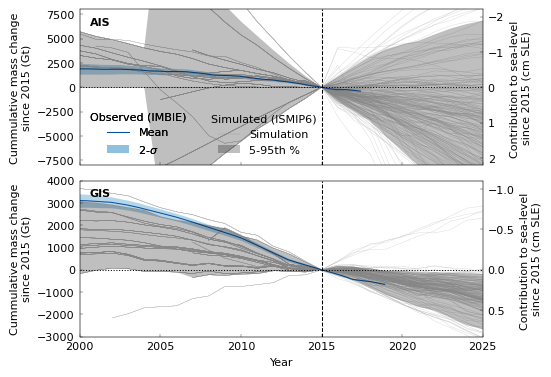

In [8]:
historical_filename = "IS_historical.pdf"
plot_historical(historical_filename, simulated=ismip6, observed=imbie)

## Figure 2: control run removed

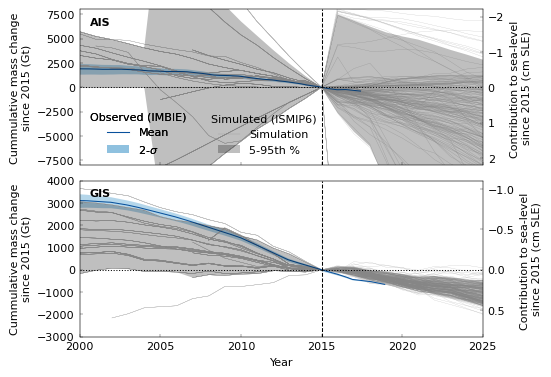

In [9]:
historical_filename = "IS_historical_ctrl_removed.pdf"
plot_historical(historical_filename, ismip6_ctrl_removed, imbie)

In [10]:
def plot_historical_partitioning(
    out_filename, simulated=None, observed=None, x_lim=[2000, 2015], ice_sheet = "GIS"):
    
    assert ice_sheet in ("AIS", "GIS")
    
    def plot_signal(g, ax):
        m_df = g[-1]
        x = m_df["Year"]
        y = m_df[f"{p_var} (Gt/yr)"]
        return ax.plot(x, y, color=simulated_signal_color, linewidth=simulated_signal_lw)

    fig, axs = plt.subplots(2, 1, sharex="col", figsize=[5.2, 4.25])
    fig.subplots_adjust(hspace=0.1, wspace=0.25)
    
    for k, p_var in enumerate(["Rate of surface mass balance anomaly", "Rate of ice dynamics anomaly"]):
        
        plot_var = f"{p_var} (Gt/yr)"
        
        if simulated is not None:
            df = simulated[simulated["IS"] == ice_sheet]

            [plot_signal(g, axs[k]) for g in df.groupby(by=["Group", "Model", "Exp"])]

            ismip6_mean = df.groupby(by="Year")[plot_var].mean().dropna()
            ismip6_low = df.groupby(by="Year")[plot_var].quantile(0.05).dropna()
            ismip6_high = df.groupby(by="Year")[plot_var].quantile(0.95).dropna()

            ismip6_ci = axs[k].fill_between(
                ismip6_mean.index,
                ismip6_low,
                ismip6_high,
                color="0.0",
                alpha=0.25,
                linewidth=0.0,
                zorder=10,
                label="5-95th %",
            )
            ismip6_line = axs[k].plot(
                ismip6_mean.index,
                ismip6_mean,
                "-",
                color="k",
                linewidth=imbie_signal_lw,
                zorder=25,
                label="Mean",
            )

        if observed is not None:
            
            imbie_cis = []
            for s, sigma in enumerate([2]):
                imbie_ci = axs[k].fill_between(
                    observed["Year"],
                    observed[f"{p_var} (Gt/yr)"] - sigma * imbie[f"{p_var} uncertainty (Gt/yr)"],
                    observed[f"{p_var} (Gt/yr)"] + sigma * imbie[f"{p_var} uncertainty (Gt/yr)"],
                    color=imbie_sigma_colors[s],
                    alpha=0.5,
                    linewidth=0,
                    zorder=20,
                    label=f"{sigma}-$\sigma$"
                )
                imbie_cis.append(imbie_ci)

            imbie_line = axs[k].plot(
                imbie["Year"],
                imbie[plot_var],
                "-",
                color=imbie_signal_color,
                linewidth=imbie_signal_lw,
                zorder=25,
                label="Mean",
            )
            axs[k].set_xlim(x_lim)
        
    if simulated is not None:
        model_line = mlines.Line2D(
            [], [], color=simulated_signal_color, linewidth=simulated_signal_lw, label="Simulation"
        )
        legend2 = axs[0].legend(handles=[ismip6_line[0], ismip6_ci], loc="lower left", bbox_to_anchor=(0.3, 0.0), title="Simulated (ISMIP6)")
        legend2.get_frame().set_linewidth(0.0)
        legend2.get_frame().set_alpha(0.0)
        axs[0].add_artist(legend2)
        
    if observed is not None:
        legend = axs[0].legend(handles=[imbie_line[0], *imbie_cis], loc="lower left", bbox_to_anchor=(0.0, 0.0), title="Observed (IMBIE)")
        legend.get_frame().set_linewidth(0.0)
        legend.get_frame().set_alpha(0.0)
        axs[0].add_artist(legend)


    axs[0].set_ylim(-250, 750)
    axs[1].set_ylim(-1000, 0)
    axs[0].set_ylabel("SMB (Gt/yr)")
    axs[1].set_ylabel("D (Gt/yr)")

    fig.savefig(out_filename, bbox_inches="tight", dpi=300)
 

## Plot flux partitioning for Greenland

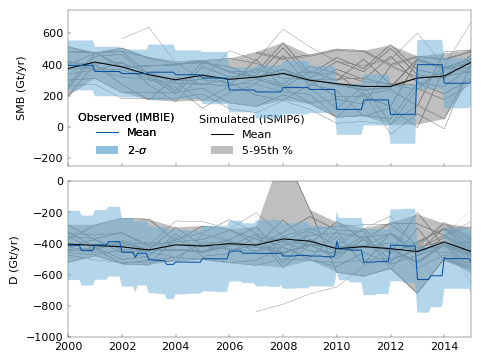

In [11]:
plot_historical_partitioning("GIS_historical_fluxes.png", simulated=ismip6, observed=imbie)

# Additional plots

## Historical trend adjusted plots

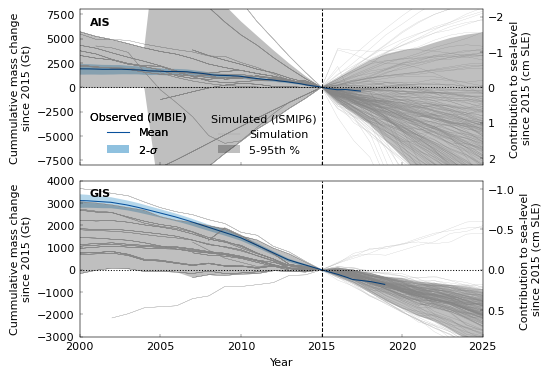

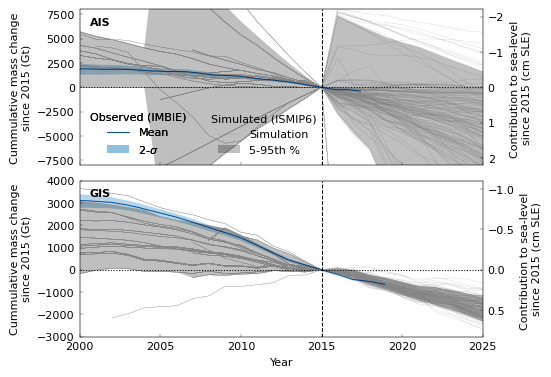

In [12]:
historical_filename = "IS_historical_adjusted.pdf"
plot_historical(historical_filename, ismip6, imbie, p_var="Hist. Adj. Cumulative ice sheet mass change")
historical_filename = "IS_historical_ctrl_removed_adjusted.pdf"
plot_historical(historical_filename, ismip6_ctrl_removed, imbie, p_var="Hist. Adj. Cumulative ice sheet mass change")

In [13]:
def plot_ice_sheet(
    out_filename, simulated=None, observed=None, ice_sheet="GIS", mean=True, x_lim=[2000, 2025], y_lim=[-5000, 5000], p_var="Cumulative ice sheet mass change", p_units="Gt"
):
    """
    Plot simulations and/or observations for a single ice sheet.
    
    Parameters
    ----------
    out_filename : string
    simulated : pandas.DataFrame or None
        A dataframe with simulations
    observed : pandas.DataFrame or None
        A dataframe with observations
    ice_sheet: string
        Must be either "AIS" or "GIS"
    mean : boolean
        If true, add mean of simulations
    x_lim : array
        Sets x-axis limits
    y_lim : array
        Sets y-axis limits

    """
    
    assert ice_sheet in ("AIS", "GIS")

    plot_var = f"{p_var} ({p_units})"
    def plot_signal(g, ax):
        m_df = g[-1]
        x = m_df["Year"]
        y = m_df[plot_var]
        return ax.plot(x, y, color=simulated_signal_color, linewidth=simulated_signal_lw)

    fig, axs = plt.subplots(1, 1, sharex="col", figsize=[5.2, 4.25])
    fig.subplots_adjust(hspace=0.1, wspace=0.25)
    
    if simulated is not None:
        df = simulated[simulated["IS"] == ice_sheet]

        [plot_signal(g, axs) for g in df.groupby(by=["Group", "Model", "Exp"])]

        ismip6_mean = df.groupby(by="Year")[plot_var].mean().dropna()
        ismip6_low = df.groupby(by="Year")[plot_var].quantile(0.05).dropna()
        ismip6_high = df.groupby(by="Year")[plot_var].quantile(0.95).dropna()

        # ismip6_ci = axs.fill_between(
        #     ismip6_mean.index,
        #     ismip6_low,   
        #     ismip6_high,
        #     color="0.0",
        #     alpha=0.25,
        #     linewidth=0.0,
        #     zorder=10,
        #     label="5-95th %",
        # )

        if mean:
            ismip6_line = axs.plot(
                ismip6_mean.index,
                ismip6_mean,
                "-",
                color="0.0",
                linewidth=imbie_signal_lw,
                label="Mean",
            )


    if observed is not None:
        imbie = observed[observed["IS"] == ice_sheet]
        imbie_cis = []
        for s, sigma in enumerate([2]):
            imbie_ci = axs.fill_between(
                imbie["Year"],
                imbie["Cumulative ice sheet mass change (Gt)"] - sigma * imbie["Cumulative ice sheet mass change uncertainty (Gt)"],
                imbie["Cumulative ice sheet mass change (Gt)"] + sigma * imbie["Cumulative ice sheet mass change uncertainty (Gt)"],
                color=imbie_sigma_colors[s],
                alpha=0.5,
                linewidth=0,
                label=f"{sigma}-$\sigma$"
            )
            imbie_cis.append(imbie_ci)

        imbie_line = axs.plot(
            imbie["Year"],
            imbie["Cumulative ice sheet mass change (Gt)"],
            "-",
            color=imbie_signal_color,
            linewidth=imbie_signal_lw,
            label="Mean",
        )
        legend = axs.legend(handles=[imbie_line[0], *imbie_cis], loc="lower left", bbox_to_anchor=(0.0, 0.0), title="Observed (IMBIE)")
        legend.get_frame().set_linewidth(0.0)
        legend.get_frame().set_alpha(0.0)
        axs.add_artist(legend)
    

    axs.axhline(0, color="k", linestyle="dotted", linewidth=grace_signal_lw)

    axs.set_xlim(x_lim[0], x_lim[1])
    axs.set_ylim(y_lim[0], y_lim[1])
    ax_sle = axs.twinx()
    ax_sle.set_ylabel(f"Contribution to sea-level \nsince {proj_start} (cm SLE)")
    ax_sle.set_ylim(-y_lim[0] * gt2cmSLE, -y_lim[1] * gt2cmSLE)
    axs.set_ylabel(f"Cummulative mass change\nsince {proj_start} ({p_units})")
    axs.text(0.025, 0.90, ice_sheet, ha="left", weight="bold", transform=axs.transAxes)
    
    # if simulated is not None:
    #     # ismip6_lines = [ismip6_line[0], ismip6_ci]
    #     # ismip6_lines = [ismip6_line[0]]
    #     legend2 = axs.legend(handles=ismip6_lines, loc="lower left", bbox_to_anchor=(0.3, 0.0), title="Simulated (ISMIP6)")
    #     legend2.get_frame().set_linewidth(0.0)
    #     legend2.get_frame().set_alpha(0.0)
    axs.set_xlabel("Year")

    fig.savefig(out_filename, bbox_inches="tight")



## Compare projections with and without adding historical mass loss trend

2000-2025

ctrl **not** removed

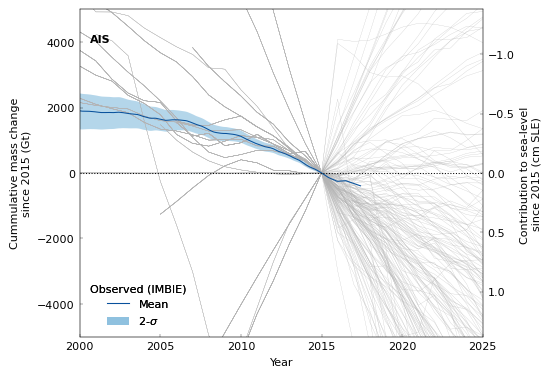

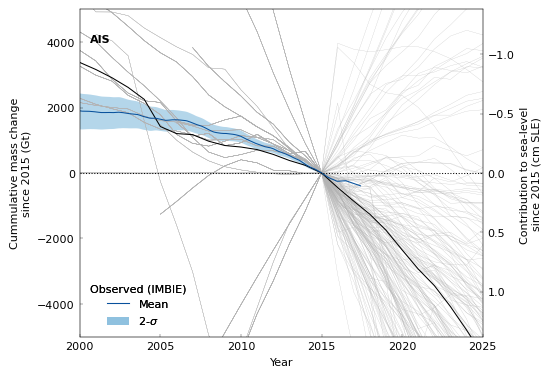

In [14]:
ice_sheet="AIS"
filename = f"{ice_sheet}_historical.pdf"
plot_ice_sheet(filename, simulated=ismip6, observed=imbie, mean=False, ice_sheet=ice_sheet, p_var="Cumulative ice sheet mass change")
filename = f"{ice_sheet}_historical_adjusted.pdf"
plot_ice_sheet(filename, simulated=ismip6, observed=imbie, ice_sheet=ice_sheet, p_var="Hist. Adj. Cumulative ice sheet mass change")

## Compare projections with and without adding historical mass loss trend

2015-2100

ctrl **not** removed

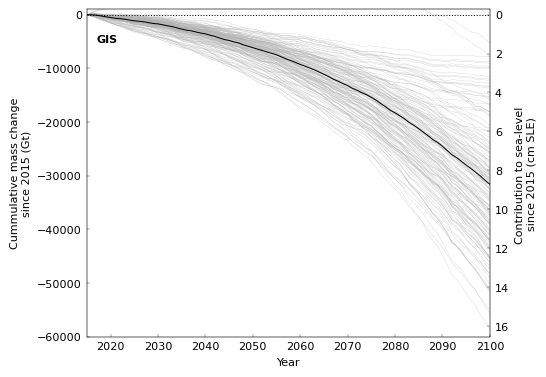

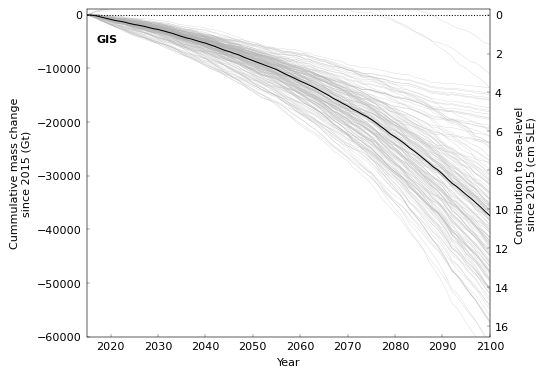

In [15]:
ice_sheet="GIS"
filename = f"{ice_sheet}_projection.pdf"
plot_ice_sheet(filename, simulated=ismip6, ice_sheet=ice_sheet, x_lim=[2015, 2100], y_lim=[-60000, 1000], p_var="Cumulative ice sheet mass change")
filename = f"{ice_sheet}_projection_adjusted.pdf"
plot_ice_sheet(filename, simulated=ismip6, ice_sheet=ice_sheet, x_lim=[2015, 2100], y_lim=[-60000, 1000], p_var="Hist. Adj. Cumulative ice sheet mass change")

## Compare projections with and without adding historical mass loss trend

2015-2100

ctrl **was** removed

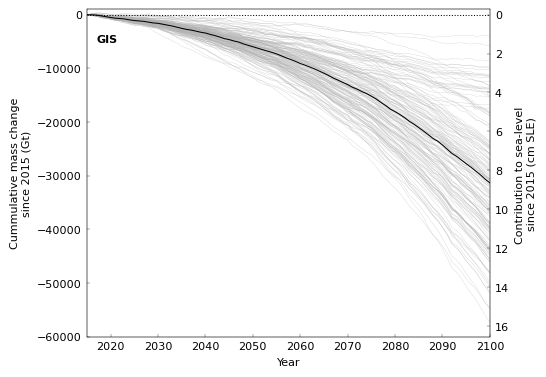

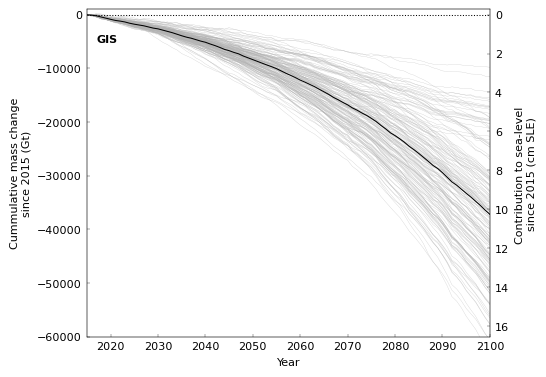

In [16]:
ice_sheet="GIS"
filename = f"{ice_sheet}_projection_ctrl_removed.pdf"
plot_ice_sheet(filename, ismip6_ctrl_removed, ice_sheet=ice_sheet, x_lim=[2015, 2100], y_lim=[-60000, 1000], p_var="Cumulative ice sheet mass change")
filename = f"{ice_sheet}_projection_ctrl_removed_adjusted.pdf"
plot_ice_sheet(filename, ismip6_ctrl_removed, ice_sheet=ice_sheet, x_lim=[2015, 2100], y_lim=[-60000, 1000], p_var="Hist. Adj. Cumulative ice sheet mass change")

## GIS with and without ctrl run removed

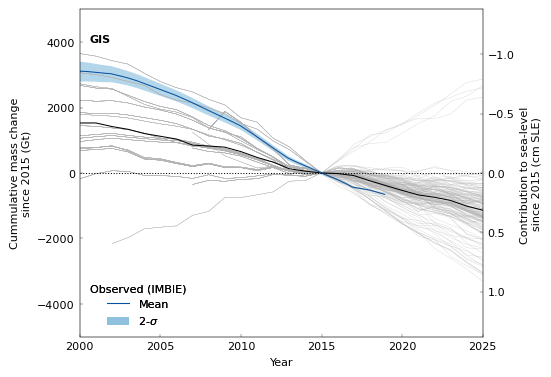

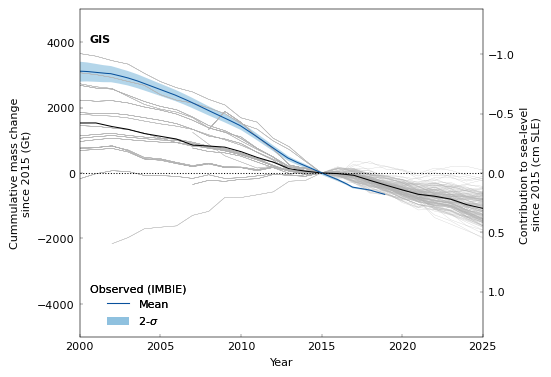

In [17]:
ice_sheet="GIS"
filename = f"{ice_sheet}_hist_with_obs.pdf"
plot_ice_sheet(filename, ismip6, imbie, ice_sheet=ice_sheet, x_lim=[2000, 2025], y_lim=[-5000, 5000], p_var="Cumulative ice sheet mass change")
filename = f"{ice_sheet}_hist_with_obs_ctrl_removed.pdf"
plot_ice_sheet(filename, ismip6_ctrl_removed, imbie, ice_sheet=ice_sheet, x_lim=[2000, 2025], y_lim=[-5000, 5000], p_var="Cumulative ice sheet mass change")

## GIS Observations only

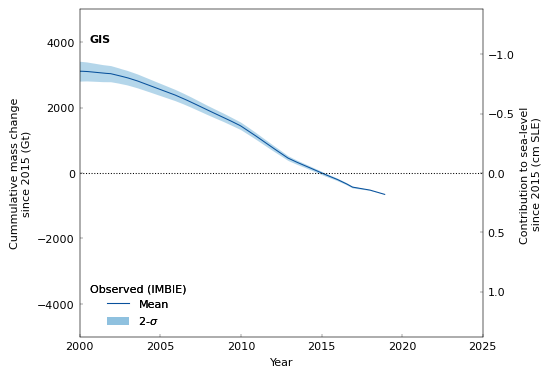

In [18]:
filename = f"{ice_sheet}_hist_only_obs.pdf"
plot_ice_sheet(filename, observed=imbie, ice_sheet=ice_sheet, x_lim=[2000, 2025], y_lim=[-5000, 5000], p_var="Cumulative ice sheet mass change")